In [94]:
# 1 Load the data file using pandas.

In [95]:
import os
import pandas as pd
import numpy as np
playstore=pd.read_csv('googleplaystore.csv')
playstore.shape

(10841, 13)

In [96]:
# Check if there are any literal 'NaN' strings in the DataFrame

In [97]:
nan_as_text = (playstore == 'NaN').sum()
print(nan_as_text)

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64


In [98]:
# 2. Check for null values in the data. Get the number of null values for each column.################

In [99]:
null_values=playstore.isnull().sum()
print(null_values)

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [100]:
# 3. Drop records with nulls in any of the columns.

In [101]:
# Drop rows with any null values
playstore_clean = playstore.dropna()
# Check the new shape after dropping
print(playstore_clean.shape)

(9360, 13)


In [102]:
# 4 Variables seem to have incorrect type and inconsistent formatting. You need to fix them

In [103]:
# 4(1) Size column has sizes in Kb as well as Mb. To analyze, you’ll need to convert these to numeric.
#      (i) Extract the numeric value from the column
#      (ii) Multiply the value by 1,000, if size is mentioned in Mb

In [104]:
# Remove rows with 'Varies with device' or '1000+' in Size column
playstore_clean = playstore_clean[~playstore_clean['Size'].str.lower().isin(['Varies with device', '1000+'])]

# Keep only valid formats: numbers followed by 'M' or 'k' (case-sensitive)
valid_mask = playstore_clean['Size'].str.match(r'^\d+(\.\d+)?[Mk]$')
playstore_clean = playstore_clean[valid_mask]

# Extract numeric part and convert to float
sizes = playstore_clean['Size'].str[:-1].astype(float)

# Extract unit part ('M' or 'k')
units = playstore_clean['Size'].str[-1]

# Convert Mb to Kb by multiplying by 1000
sizes = sizes.where(units == 'k', sizes * 1000)

# Assign cleaned numeric values back to the DataFrame
playstore_clean['Size'] = sizes


# Verify conversion
print(playstore_clean['Reviews'].head())

0       159
1       967
2     87510
3    215644
4       967
Name: Reviews, dtype: object


In [105]:
# 4(2) Reviews is a numeric field that is loaded as a string field. Convert it to numeric (int/float)

In [106]:
# Drop rows where 'Reviews' column value is '3.0M'
playstore_clean = playstore_clean[playstore_clean['Reviews'] != '3.0M']

# Now convert Reviews column to numeric type (int)
playstore_clean['Reviews'] = playstore_clean['Reviews'].astype(int)

# Verify conversion
print(playstore_clean['Reviews'].head())


0       159
1       967
2     87510
3    215644
4       967
Name: Reviews, dtype: int64


In [107]:
# 4(3) Installs field is currently stored as string and has values like 1,000,000+. 
#       (i) Treat 1,000,000+ as 1,000,000
#       (ii) remove ‘+’, ‘,’ from the field, convert it to integer

In [108]:
# Remove ',' and '+' from the 'Installs' column and convert to integer
playstore_clean['Installs'] = playstore_clean['Installs'].str.replace(',', '', regex=False)  # Remove commas
playstore_clean['Installs'] = playstore_clean['Installs'].str.replace('+', '', regex=False)  # Remove plus signs

# Convert to integer type
playstore_clean['Installs'] = playstore_clean['Installs'].astype(int)

# Verify conversion
print(playstore_clean['Installs'].head())

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64


In [109]:
# 4(4) Price field is a string and has $ symbol. Remove ‘$’ sign, and convert it to numeric.

In [110]:
# Remove rows with 'Everyone' in Price column
playstore_clean = playstore_clean[~playstore_clean['Price'].str.contains('Everyone', na=False)]

# Remove '$' sign
playstore_clean['Price'] = playstore_clean['Price'].str.replace('$', '', regex=False)

# Convert to float to handle decimals like '4.99'
playstore_clean['Price'] = playstore_clean['Price'].astype(float)

print(playstore_clean['Price'].head())

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64


In [111]:
# 5. Sanity checks:
#   (1) Average rating should be between 1 and 5 as only these values are allowed on the play store. Drop the rows that have a value outside this range.
#   (2) Reviews should not be more than installs as only those who installed can review the app. If there are any such records, drop them.
#   (3) For free apps (type = “Free”), the price should not be >0. Drop any such rows.

In [112]:
# 1. Drop rows where 'Rating' is not between 1 and 5 (inclusive)
playstore_clean = playstore_clean[(playstore_clean['Rating'] >= 1) & (playstore_clean['Rating'] <= 5)]

# 2. Drop rows where 'Reviews' is more than 'Installs'
playstore_clean = playstore_clean[playstore_clean['Reviews'] <= playstore_clean['Installs']]

# 3. For free apps (Type == 'Free'), drop rows where Price is greater than 0
playstore_clean = playstore_clean[~((playstore_clean['Type'] == 'Free') & (playstore_clean['Price'] > 0))]

# Display number of rows after cleaning and check sample of data to verify
print(f"Number of rows after sanity checks: {playstore_clean.shape[0]}")
print(playstore_clean[['Rating', 'Reviews', 'Installs', 'Type', 'Price']].head())


Number of rows after sanity checks: 7717
   Rating  Reviews  Installs  Type  Price
0     4.1      159     10000  Free    0.0
1     3.9      967    500000  Free    0.0
2     4.7    87510   5000000  Free    0.0
3     4.5   215644  50000000  Free    0.0
4     4.3      967    100000  Free    0.0


In [113]:
# 5. Performing univariate analysis: 

In [114]:
# 5(A) Boxplot for Price
#      Are there any outliers? Think about the price of usual apps on Play Store.

In [115]:
playstore_clean

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10833,Chemin (fr),BOOKS_AND_REFERENCE,4.8,44,619.0,1000,Free,0.0,Everyone,Books & Reference,"March 23, 2014",0.8,2.2 and up
10834,FR Calculator,FAMILY,4.0,7,2600.0,500,Free,0.0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53000.0,5000,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3600.0,100,Free,0.0,Everyone,Education,"July 6, 2018",1,4.1 and up


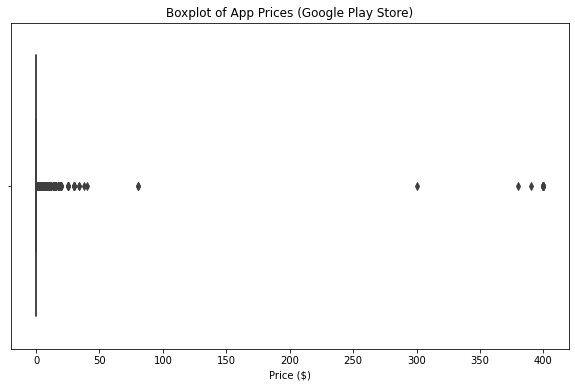

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(x=playstore_clean['Price'])
plt.title('Boxplot of App Prices (Google Play Store)')
plt.xlabel('Price ($)')
plt.show()

In [117]:
# 5(B) Boxplot for Reviews
#      Are there any apps with very high number of reviews? Do the values seem right?

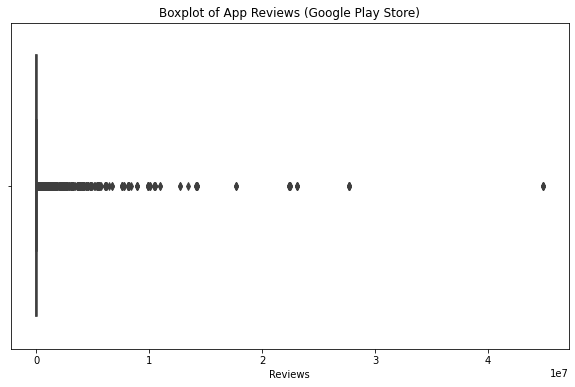

In [118]:
plt.figure(figsize=(10,6))
sns.boxplot(x=playstore_clean['Reviews'])
plt.title('Boxplot of App Reviews (Google Play Store)')
plt.xlabel('Reviews')
plt.show()

In [119]:
# Calculate quartiles and IQR
Q1 = np.percentile(playstore_clean.Reviews,[25,75])[0]
Q3 = np.percentile(playstore_clean.Reviews,[25,75])[1]
IQR = Q3 - Q1
# Define outlier bounds
LowerLimit = Q1 - 1.5 * IQR
UpperLimit = Q3 + 1.5 * IQR

print('Quartile 1 is: ',+Q1)
print('Quartile 3 is: ',+Q3)
print('Inter Quartile Range is: ',+IQR)
print('Upper Limit is: ',+UpperLimit)
print('Lower Limit is: ',+LowerLimit)

# Detect outliers
outliers = playstore_clean[(playstore_clean['Reviews'] < LowerLimit) | (playstore_clean['Reviews'] > UpperLimit)]
print(f"\nNumber of outliers detected: {outliers.shape[0]}")

Quartile 1 is:  109.0
Quartile 3 is:  39109.0
Inter Quartile Range is:  39000.0
Upper Limit is:  97609.0
Lower Limit is:  -58391.0

Number of outliers detected: 1326


In [120]:
# Most apps have a relatively low number of reviews — the bulk of the data lies within the box (between the 25th and 75th percentiles).
# The presence of 1326 outliers beyond the upper whisker indicates a significant number of apps with exceptionally high review counts.
# These outlier review counts are plausible given popular apps with millions of users, which realistically receive millions of reviews.

In [121]:
# 5(C) Histogram for Rating
#     How are the ratings distributed? Is it more toward higher ratings?

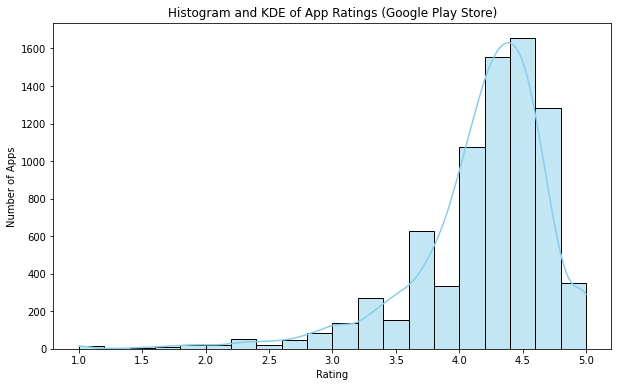

In [122]:
# Plot histogram with KDE overlay for Rating
plt.figure(figsize=(10,6))
sns.histplot(playstore_clean['Rating'], bins=20, kde=True, color='skyblue')
plt.title('Histogram and KDE of App Ratings (Google Play Store)')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.show()

In [123]:
# The distribution of app ratings is expected to be strongly left-skewed,
# meaning most ratings are clustered towards the higher end (close to 5), with fewer apps rated low.
# This pattern indicates users generally give higher ratings, consistent with app store behavior.

In [124]:
# 6(4) Histogram for Size

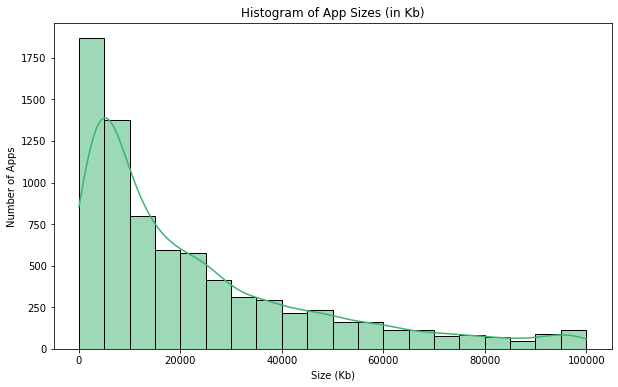

In [125]:
plt.figure(figsize=(10,6))
sns.histplot(playstore_clean['Size'], bins=20, kde=True, color='mediumseagreen')
plt.title('Histogram of App Sizes (in Kb)')
plt.xlabel('Size (Kb)')
plt.ylabel('Number of Apps')
plt.show()

In [126]:
# 6. Outlier treatment: 

In [127]:
# 6 (1) Price: From the box plot, it seems like there are some apps with very high price. A price of $200 for an application on the Play Store is very high and suspicious!
#       Check out the records with very high price
#       Is 200 indeed a high price?
#       Drop these as most seem to be junk apps

In [128]:
import numpy as np

# Calculate third quartile and IQR for Price
Q1 = np.percentile(playstore_clean['Price'], 25)
Q3 = np.percentile(playstore_clean['Price'], 75)
IQR = Q3 - Q1
UpperLimit = Q3 + 1.5 * IQR

print('Q3 (75th percentile):', Q3)
print('IQR:', IQR)
print('UpperLimit for outliers:', UpperLimit)

# Filter and display records with price above the upper whisker
high_price_records = playstore_clean[playstore_clean['Price'] > UpperLimit]
print("Apps with price greater than Q3 + 1.5*IQR (possible junk apps):")
print(high_price_records[['App', 'Price']])

# Is $200 a high price?
if 200 > UpperLimit:
    print(f"$200 is an outlier (above Q3+1.5*IQR). Such a price is very high and likely suspicious for Play Store apps.")
else:
    print(f"$200 is not an outlier based on the 1.5*IQR rule, though it would still be considered unusual.")

# Drop outlier records (price above upper whisker)
playstore_clean = playstore_clean[playstore_clean['Price'] <= UpperLimit]

# Document the action:
# Dropped records with price greater than Q3+1.5*IQR, as these are statistically outliers and likely junk apps.


Q3 (75th percentile): 0.0
IQR: 0.0
UpperLimit for outliers: 0.0
Apps with price greater than Q3 + 1.5*IQR (possible junk apps):
                                                 App  Price
234    TurboScan: scan documents and receipts in PDF   4.99
235                   Tiny Scanner Pro: PDF Doc Scan   4.99
290    TurboScan: scan documents and receipts in PDF   4.99
291                   Tiny Scanner Pro: PDF Doc Scan   4.99
477                                       Calculator   6.99
...                                              ...    ...
10682                            Fruit Ninja Classic   0.99
10690                                       FO Bixby   0.99
10760                                Fast Tract Diet   7.99
10782                        Trine 2: Complete Story  16.99
10785                                   sugar, sugar   1.20

[575 rows x 2 columns]
$200 is an outlier (above Q3+1.5*IQR). Such a price is very high and likely suspicious for Play Store apps.


In [129]:
# 7(2) Reviews: Very few apps have very high number of reviews. These are all star apps that don’t help with the analysis and, in fact, will skew it. Drop records having more than 2 million reviews.

In [130]:
# Drop records where Reviews are greater than 2,000,000
playstore_clean = playstore_clean[playstore_clean['Reviews'] <= 2_000_000]

In [131]:
# 7(3) Installs:  There seems to be some outliers in this field too. Apps having very high number of installs should be dropped from the analysis.
#         Find out the different percentiles – 10, 25, 50, 70, 90, 95, 99
#         Decide a threshold as cutoff for outlier and drop records having values more than that

In [132]:
# 1. Calculate required percentiles for 'Installs'
percentiles = [10, 25, 50, 70, 90, 95, 99]
percentile_values = np.percentile(playstore_clean['Installs'], percentiles)

# Print percentile values for inspection
for p, val in zip(percentiles, percentile_values):
    print(f"{p}th percentile of Installs: {val}")

# 2. Define lower and upper cutoff thresholds based on 10th and 99th percentiles
lower_cutoff = percentile_values[0]  # 10th percentile
upper_cutoff = percentile_values[-1]  # 99th percentile

print(f"\nFiltering Installs values outside the range [{lower_cutoff}, {upper_cutoff}]")

# 3. Drop rows with 'Installs' less than 10th percentile or greater than 99th percentile
playstore_clean = playstore_clean[(playstore_clean['Installs'] >= lower_cutoff) & 
                                  (playstore_clean['Installs'] <= upper_cutoff)]

# Documenting action:
# Dropped app records with 'Installs' below 10th percentile and above 99th percentile to remove outliers from analysis.

10th percentile of Installs: 1000.0
25th percentile of Installs: 10000.0
50th percentile of Installs: 100000.0
70th percentile of Installs: 1000000.0
90th percentile of Installs: 10000000.0
95th percentile of Installs: 10000000.0
99th percentile of Installs: 50000000.0

Filtering Installs values outside the range [1000.0, 50000000.0]


In [133]:
# 8. Bivariate analysis: Let’s look at how the available predictors relate to the variable of interest, i.e., our target variable rating. Make scatter plots (for numeric features) and box plots (for character features) to assess the relations between rating and the other features.

In [134]:
# 8(A) Make scatter plot/joinplot for Rating vs. Price
#.     What pattern do you observe? Does rating increase with price?

Text(0, 0.5, 'Price')

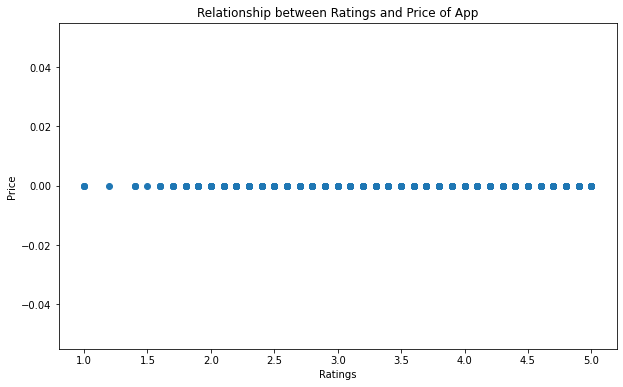

In [135]:
# Scatter plot for Rating vs Price
plt.figure(figsize=(10,6))
plt.scatter(playstore_clean.Rating,playstore_clean.Price)
plt.title('Relationship between Ratings and Price of App')
plt.xlabel('Ratings')
plt.ylabel('Price')

In [136]:
# Most apps in the data are free (have a price of 0), so all their price points are at zero on the y-axis.

In [137]:
# 8(2) Make scatter plot/joinplot for Rating vs. Size
#.     Are heavier apps rated better?

Text(0, 0.5, 'Size')

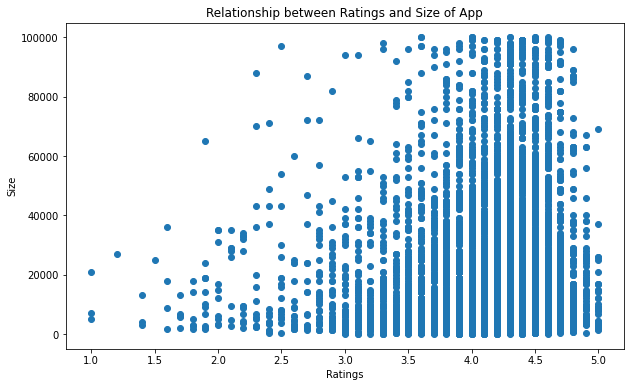

In [138]:
# Scatter plot for Rating vs Size
plt.figure(figsize=(10,6))
plt.scatter(playstore_clean.Rating,playstore_clean.Size)
plt.title('Relationship between Ratings and Size of App')
plt.xlabel('Ratings')
plt.ylabel('Size')

In [139]:
# Heavier apps are not clearly rated better. The ratings of apps do not show a significant increase with app size based on your plot.

In [140]:
# 7(C) Make scatter plot/joinplot for Rating vs. Reviews
#.     Does more review mean a better rating always?

Text(0, 0.5, 'Reviews')

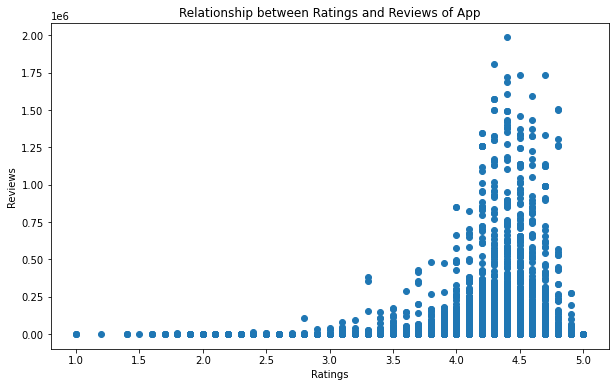

In [141]:
# Scatter plot for Rating vs Reviews
plt.figure(figsize=(10,6))
plt.scatter(playstore_clean.Rating,playstore_clean.Reviews)
plt.title('Relationship between Ratings and Reviews of App')
plt.xlabel('Ratings')
plt.ylabel('Reviews')

In [142]:
# More reviews do not always mean higher ratings—popular apps may be well-rated, but high review counts are found across a range of ratings. The relationship is not strong or linear.

In [143]:
# 4(D) Make boxplot for Rating vs. Content Rating
#      Is there any difference in the ratings? Are some types liked better?

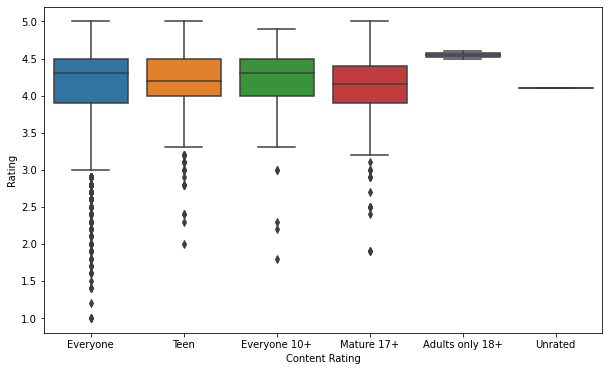

In [144]:
plt.figure(figsize=(10,6))
sns.boxplot(x=playstore_clean['Content Rating'],y=playstore_clean['Rating'])
plt.xlabel('Content Rating')
plt.ylabel('Rating')
plt.show()

In [145]:
#There is no major difference in ratings across content rating types on the Play Store. 
#Apps rated for “Everyone,” “Teen,” or “Mature” are all similarly liked, based on user ratings. 
#Some slight variation exists, but it is not enough to say that one category is strongly preferred over the others.

In [146]:
# 8(E) Make boxplot for Ratings vs. Category
#.     Which genre has the best ratings?

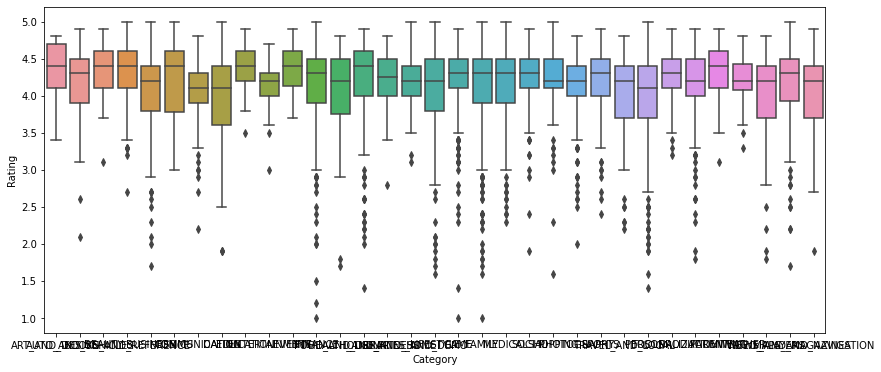

In [147]:
plt.figure(figsize=(14,6))
sns.boxplot(x=playstore_clean['Category'],y=playstore_clean['Rating'])
plt.xlabel('Category')
plt.ylabel('Rating')
plt.show()

In [148]:
# According to the boxplot, the genres like "Events" or "Education" appear to have the highest median ratings, though the difference between categories is minor. 
# Most categories are generally well rated, with only subtle variations between them.

In [149]:
# 9 Data preprocessing
# For the steps below, create a copy of the dataframe to make all the edits. Name it inp1.

In [150]:
# 9(A) Reviews and Install have some values that are still relatively very high. 
#Before building a linear regression model, you need to reduce the skew. 
#Apply log transformation (np.log1p) to Reviews and Installs.

In [151]:
# Apply log transformation using np.log1p (which applies log(1 + x))
inp1 = playstore_clean.copy()
inp1['Review_log'] = np.log1p(inp1['Reviews'])
inp1['Install_log'] = np.log1p(inp1['Installs'])

In [152]:
# 9(B) Drop columns App, Last Updated, Current Ver, and Android Ver. 
# These variables are not useful for our task.

In [153]:
inp1 = inp1.drop(columns=['App', 'Last Updated', 'Current Ver', 'Android Ver'])
inp1

,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Review_log,Install_log
0,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,5.075174,9.210440
1,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,6.875232,13.122365
2,ART_AND_DESIGN,4.7,87510,8700.0,5000000,Free,0.0,Everyone,Art & Design,11.379520,15.424949
3,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,12.281389,17.727534
4,ART_AND_DESIGN,4.3,967,2800.0,100000,Free,0.0,Everyone,Art & Design;Creativity,6.875232,11.512935
...,...,...,...,...,...,...,...,...,...,...,...
10830,NEWS_AND_MAGAZINES,3.8,881,2300.0,100000,Free,0.0,Everyone,News & Magazines,6.782192,11.512935
10832,WEATHER,3.8,1195,582.0,100000,Free,0.0,Everyone,Weather,7.086738,11.512935
10833,BOOKS_AND_REFERENCE,4.8,44,619.0,1000,Free,0.0,Everyone,Books & Reference,3.806662,6.908755
10836,FAMILY,4.5,38,53000.0,5000,Free,0.0,Everyone,Education,3.663562,8.517393


In [154]:
# 9(3) Get dummy columns for Category, Genres, and Content Rating. 
# This needs to be done as the models do not understand categorical data, and all data should be numeric. 
# Dummy encoding is one way to convert character fields to numeric. 
# Name of dataframe should be inp2.

In [155]:
import pandas as pd

inp2 = inp1.copy()

# Create dummy variables for each categorical column separately
dummies_cat = pd.get_dummies(inp2['Category'], prefix='Category', drop_first=True)
dummies_genres = pd.get_dummies(inp2['Genres'], prefix='Genres', drop_first=True)
dummies_content = pd.get_dummies(inp2['Content Rating'], prefix='ContentRating', drop_first=True)
dummies_type = pd.get_dummies(inp2['Type'], prefix='Type', drop_first=True)

# Concatenate all dummy columns to inp2
inp2 = pd.concat([inp2, dummies_cat, dummies_genres, dummies_content, dummies_type], axis=1)

# Drop the original categorical columns
inp2.drop(columns=['Category', 'Genres', 'Content Rating', 'Type'], inplace=True)

# Check the columns of the updated dataframe
print(inp2.columns)


Index(['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Review_log',
       'Install_log', 'Category_AUTO_AND_VEHICLES', 'Category_BEAUTY',
       'Category_BOOKS_AND_REFERENCE',
       ...
       'Genres_Video Players & Editors',
       'Genres_Video Players & Editors;Creativity',
       'Genres_Video Players & Editors;Music & Video', 'Genres_Weather',
       'Genres_Word', 'ContentRating_Everyone', 'ContentRating_Everyone 10+',
       'ContentRating_Mature 17+', 'ContentRating_Teen',
       'ContentRating_Unrated'],
      dtype='object', length=151)


In [156]:
inp2

,Rating,Reviews,Size,Installs,Price,Review_log,Install_log,Category_AUTO_AND_VEHICLES,Category_BEAUTY,Category_BOOKS_AND_REFERENCE,...,Genres_Video Players & Editors,Genres_Video Players & Editors;Creativity,Genres_Video Players & Editors;Music & Video,Genres_Weather,Genres_Word,ContentRating_Everyone,ContentRating_Everyone 10+,ContentRating_Mature 17+,ContentRating_Teen,ContentRating_Unrated
0,4.1,159,19000.0,10000,0.0,5.075174,9.210440,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,3.9,967,14000.0,500000,0.0,6.875232,13.122365,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,4.7,87510,8700.0,5000000,0.0,11.379520,15.424949,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4.5,215644,25000.0,50000000,0.0,12.281389,17.727534,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,4.3,967,2800.0,100000,0.0,6.875232,11.512935,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10830,3.8,881,2300.0,100000,0.0,6.782192,11.512935,0,0,0,...,0,0,0,0,0,1,0,0,0,0
10832,3.8,1195,582.0,100000,0.0,7.086738,11.512935,0,0,0,...,0,0,0,1,0,1,0,0,0,0
10833,4.8,44,619.0,1000,0.0,3.806662,6.908755,0,0,1,...,0,0,0,0,0,1,0,0,0,0
10836,4.5,38,53000.0,5000,0.0,3.663562,8.517393,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [157]:
# 10 Train test split  and apply 70-30 split. 
# Name the new dataframes df_train and df_test.

In [158]:
# Define feature matrix X by dropping the target variable from dataframe
x=inp2.drop(['Rating','Reviews','Installs'],axis=1)
x

,Size,Price,Review_log,Install_log,Category_AUTO_AND_VEHICLES,Category_BEAUTY,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMICS,Category_COMMUNICATION,...,Genres_Video Players & Editors,Genres_Video Players & Editors;Creativity,Genres_Video Players & Editors;Music & Video,Genres_Weather,Genres_Word,ContentRating_Everyone,ContentRating_Everyone 10+,ContentRating_Mature 17+,ContentRating_Teen,ContentRating_Unrated
0,19000.0,0.0,5.075174,9.210440,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,14000.0,0.0,6.875232,13.122365,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,8700.0,0.0,11.379520,15.424949,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,25000.0,0.0,12.281389,17.727534,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,2800.0,0.0,6.875232,11.512935,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10830,2300.0,0.0,6.782192,11.512935,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
10832,582.0,0.0,7.086738,11.512935,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
10833,619.0,0.0,3.806662,6.908755,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
10836,53000.0,0.0,3.663562,8.517393,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [159]:
# Define target variable y (Rating)
y = inp2['Rating']
y

0        4.1
1        3.9
2        4.7
3        4.5
4        4.3
        ... 
10830    3.8
10832    3.8
10833    4.8
10836    4.5
10840    4.5
Name: Rating, Length: 6366, dtype: float64

In [160]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.30)
# Combine X and y to form training and testing DataFrames
df_train = x_train.copy()
df_train['Rating'] = y_train

df_test = x_test.copy()
df_test['Rating'] = y_test

In [161]:
# 11 Separate the dataframes into X_train, y_train, X_test, and y_test.

In [162]:
# Separate features and target in training set
y_train = df_train['Rating']
X_train = df_train.drop(columns=['Rating'])

# Separate features and target in test set
y_test = df_test['Rating']
X_test = df_test.drop(columns=['Rating'])

In [163]:
# 12. Model building
# Use linear regression as the technique
# Report the R2 on the train set

In [165]:
from sklearn.linear_model import LinearRegression
inp2_lm=LinearRegression().fit(x_train,y_train)

In [166]:
inp2_lm.intercept_

4.229624428339189

In [167]:
inp2_lm.coef_

array([-3.16757763e-07, -7.97249766e-12,  1.51408092e-01, -1.18311568e-01,
        2.05903811e-01,  3.78293006e-01,  2.71416489e-01,  1.59865851e-01,
        1.73349866e-01,  1.10598201e-01,  1.00365228e-01,  9.07661047e-02,
        1.27455805e-01,  2.80490782e-01,  1.32213224e-01,  1.32446018e-01,
        1.21537048e-01,  3.16811571e-01,  1.58969926e-01,  1.78443416e-01,
        2.38445480e-01,  1.23003221e-01,  9.22651610e-02,  2.16973402e-01,
        1.43003773e-01,  3.59139703e-01,  2.42223869e-01,  1.27168920e-01,
        1.54253811e-01,  1.70390554e-01,  1.79200722e-01,  1.70860487e-02,
        9.94891050e-02,  1.06217806e-01,  1.32210378e-01,  1.79723045e-01,
        1.97798801e-01, -7.86082218e-02,  2.76821822e-01, -5.71849178e-02,
       -1.03576667e-02,  3.13305102e-01,  4.48669696e-01,  6.57913813e-01,
        6.38108787e-01,  2.91857099e-01,  2.05903811e-01,  3.78293006e-01,
        5.06828592e-02,  1.03082032e-01,  3.59743783e-01,  2.71416489e-01,
       -2.32605042e-01,  

In [169]:
predicted_ratings=pd.DataFrame(inp2_lm.predict(x_train),columns=['Predicted_Ratings'])
predicted_ratings

,Predicted_Ratings
0,4.183308
1,4.259058
2,4.057297
3,3.860313
4,3.859542
...,...
4451,3.986125
4452,3.793951
4453,4.380536
4454,4.498439


In [170]:
test_final=pd.concat([x_train.reset_index(drop=True),y_train.reset_index(drop=True),predicted_ratings],axis=1)
test_final

,Size,Price,Review_log,Install_log,Category_AUTO_AND_VEHICLES,Category_BEAUTY,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMICS,Category_COMMUNICATION,...,Genres_Video Players & Editors;Music & Video,Genres_Weather,Genres_Word,ContentRating_Everyone,ContentRating_Everyone 10+,ContentRating_Mature 17+,ContentRating_Teen,ContentRating_Unrated,Rating,Predicted_Ratings
0,19000.0,0.0,9.986495,13.815512,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,4.3,4.183308
1,8200.0,0.0,11.532316,15.424949,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,4.4,4.259058
2,15000.0,0.0,4.077537,9.210440,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,4.4,4.057297
3,7900.0,0.0,3.258097,8.517393,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,4.4,3.860313
4,49000.0,0.0,9.287949,15.424949,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,4.3,3.859542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4451,56000.0,0.0,7.846590,11.512935,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,4.1,3.986125
4452,3100.0,0.0,5.948035,11.512935,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,3.5,3.793951
4453,8600.0,0.0,11.046770,13.122365,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,4.6,4.380536
4454,30000.0,0.0,13.319170,16.118096,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,4.2,4.498439


In [171]:
test_final['err_pct']=abs(test_final.Rating-test_final.Predicted_Ratings)/test_final.Rating
test_final

,Size,Price,Review_log,Install_log,Category_AUTO_AND_VEHICLES,Category_BEAUTY,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMICS,Category_COMMUNICATION,...,Genres_Weather,Genres_Word,ContentRating_Everyone,ContentRating_Everyone 10+,ContentRating_Mature 17+,ContentRating_Teen,ContentRating_Unrated,Rating,Predicted_Ratings,err_pct
0,19000.0,0.0,9.986495,13.815512,0,0,0,0,0,0,...,0,0,1,0,0,0,0,4.3,4.183308,0.027138
1,8200.0,0.0,11.532316,15.424949,0,0,0,0,0,0,...,0,0,1,0,0,0,0,4.4,4.259058,0.032032
2,15000.0,0.0,4.077537,9.210440,0,0,0,0,0,0,...,0,0,1,0,0,0,0,4.4,4.057297,0.077887
3,7900.0,0.0,3.258097,8.517393,0,0,0,1,0,0,...,0,0,1,0,0,0,0,4.4,3.860313,0.122656
4,49000.0,0.0,9.287949,15.424949,0,0,0,0,0,0,...,0,0,1,0,0,0,0,4.3,3.859542,0.102432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4451,56000.0,0.0,7.846590,11.512935,0,0,0,0,0,0,...,0,0,0,0,1,0,0,4.1,3.986125,0.027774
4452,3100.0,0.0,5.948035,11.512935,0,0,0,0,0,0,...,0,0,1,0,0,0,0,3.5,3.793951,0.083986
4453,8600.0,0.0,11.046770,13.122365,0,0,0,0,0,0,...,0,0,0,0,1,0,0,4.6,4.380536,0.047710
4454,30000.0,0.0,13.319170,16.118096,0,0,0,0,0,0,...,0,0,1,0,0,0,0,4.2,4.498439,0.071057


In [172]:
# Overall error i.e.avg error pct
test_final.err_pct.mean()

0.0917419205088032

In [173]:
# Model accuracy rate
1 - test_final.err_pct.mean()

0.9082580794911967

In [175]:
# R square - Higher the better ranges from range of 0 to 1. Explains the variability in model
from sklearn.metrics import r2_score
# r2_score(actual_y_variable,predicted_y_variable)
r2_score(test_final.Rating,test_final.Predicted_Ratings)

0.16682819767168922

In [176]:
# 13. Make predictions on test set and report R2.

In [177]:
# Predict ratings on test set features
predicted_ratings_test = pd.DataFrame(inp2_lm.predict(x_test), columns=['Predicted_Ratings'])

# Combine predictions with actual test data (features + true ratings)
test_results = pd.concat([x_test.reset_index(drop=True), y_test.reset_index(drop=True), predicted_ratings_test], axis=1)

# Calculate error percentage on test set
test_results['err_pct'] = abs(test_results['Rating'] - test_results['Predicted_Ratings']) / test_results['Rating']

# Calculate and print overall average error percentage on test set
avg_error_pct_test = test_results['err_pct'].mean()
print(f"Overall average error percentage (test set): {avg_error_pct_test}")

# Calculate and print model accuracy rate on test set
accuracy_rate_test = 1 - avg_error_pct_test
print(f"Model accuracy rate (test set): {accuracy_rate_test}")

# Calculate and print R^2 score on test set
r2_test = r2_score(test_results['Rating'], test_results['Predicted_Ratings'])
print(f"R² on test set: {r2_test}")


Overall average error percentage (test set): 0.09393941244670798
Model accuracy rate (test set): 0.906060587553292
R² on test set: 0.17349670535989248
